<a href="https://colab.research.google.com/github/neurostatslab/error-in-variables-garon-2026/blob/main/demo_notebooks/eiv_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/neurostatslab/error-in-variables-garon-2026.git
import sys
sys.path.append('error-in-variables-garon-2026/')

Cloning into 'error-in-variables-garon-2026'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 144 (delta 84), reused 41 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 8.49 MiB | 10.17 MiB/s, done.
Resolving deltas: 100% (84/84), done.


In [ ]:

!pip install -U "jax[cuda12]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

!pip install jaxopt
!pip install distrax

import jax

import jaxopt
import jax.numpy as jnp
from jax.nn import softplus
from jax.scipy.special import logsumexp

import matplotlib.pyplot as plt

from functools import partial
from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

import utils
import mappings
import noise_models
from core import GPLVM, Layer
from mc_samplers import Roberts


Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.7 MB/s eta 0:00:00
  Attempting uninstall: jax-cuda12-pjrt
    Found existing installation: jax-cuda12-pjrt 0.7.2
    Uninstalling jax-cuda12-pjrt-0.7.2:
      Successfully uninstalled jax-cuda12-pjrt-0.7.2
  Attempting uninstall: jax-cuda12-plugin
    Found existing installation: jax-cuda12-plugin 0.7.2
    Uninstalling jax-cuda12-plugin-0.7.2:
      Successfully uninstalled jax-cuda12-plugin-0.7.2
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.

# Fit Model

### Construct Model Params

In [ ]:
# Model/Generative Hyperparams

num_neurons = 30
num_dims = 1
num_steps = 1000

kappa = 5.

basis_params = {
                "max_freq": 30,
                "num_dims": num_dims,
                "out_scale":10.,
                "len_scale":.1,
                "bias_mean": 0,
                "bias_std": 0,
                "num_neurons":num_neurons,
                "tol":1e-3,
                "nonlinearity":lambda x: softplus(x),
                }



# KEY DUMP
GEN_KEY = jax.random.PRNGKey(17)
INIT_KEY = jax.random.PRNGKey(25)
OPT_KEY = jax.random.PRNGKey(123)

# Construct Model
model = GPLVM(
    observation=Layer(
            mapping=mappings.EIVMapping([mappings.WeightedFourierBasisMapping(basis_params),
                                            mappings.IdentityMapping()]),
            noise=noise_models.EIVNoiseModel([noise_models.Poisson(),noise_models.VonMisesNormed(kappa)])
            ),
    sampler = Roberts(num_dims, mc_scale=1))

params_per_neuron = model.params_per_neuron


### Simulate Data

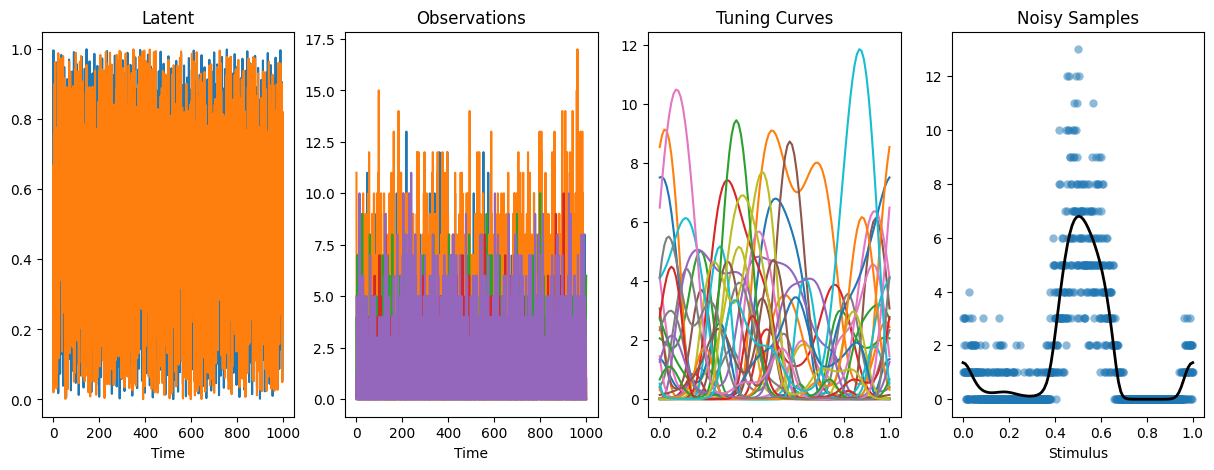

In [ ]:

# Sample true parameters of model
true_weights = jax.random.normal(
                        GEN_KEY, shape=(params_per_neuron, num_neurons)
                    )

x_grid = utils.make_xgrid(1, 100, 1.)
true_tunings = model.observation.mapping(true_weights, x_grid)[0].T


xs_true, ys = model.simulate(
    key=GEN_KEY,
    params=true_weights,
    num_observations=num_steps
)

#Visualize Dataset
utils.plot_simulated_data_1D(xs_true, true_weights, ys, model);

### Fit Model

In [ ]:

est_params = jax.random.normal(
                        INIT_KEY,
                        shape=(params_per_neuron, num_neurons)
                    )

opt_params = {
    "init_params":est_params,
    "save_prior":True,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "n_iters":  200
}

model.fit(ys, "lbfgs", opt_params)


100%|██████████| 200/200 [00:07<00:00, 25.46it/s]


### Plot Results

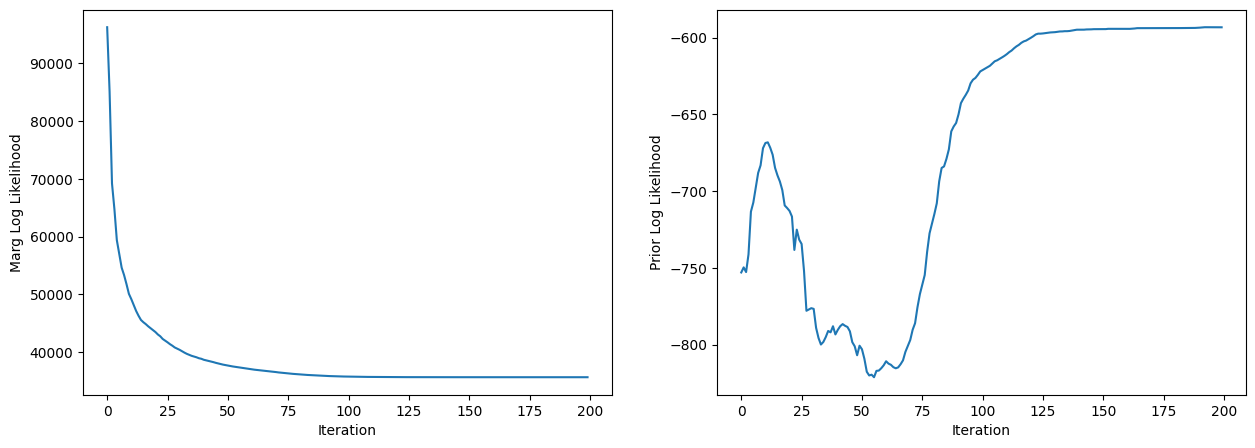

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


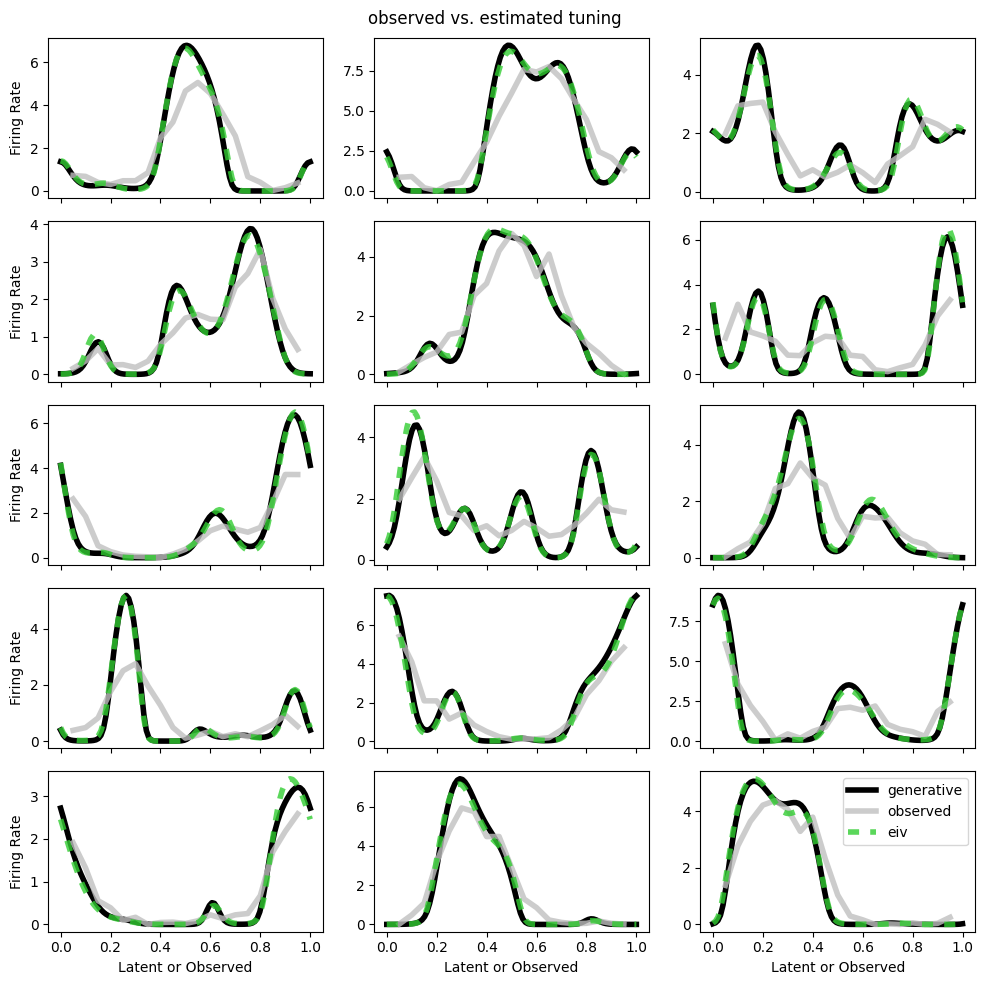

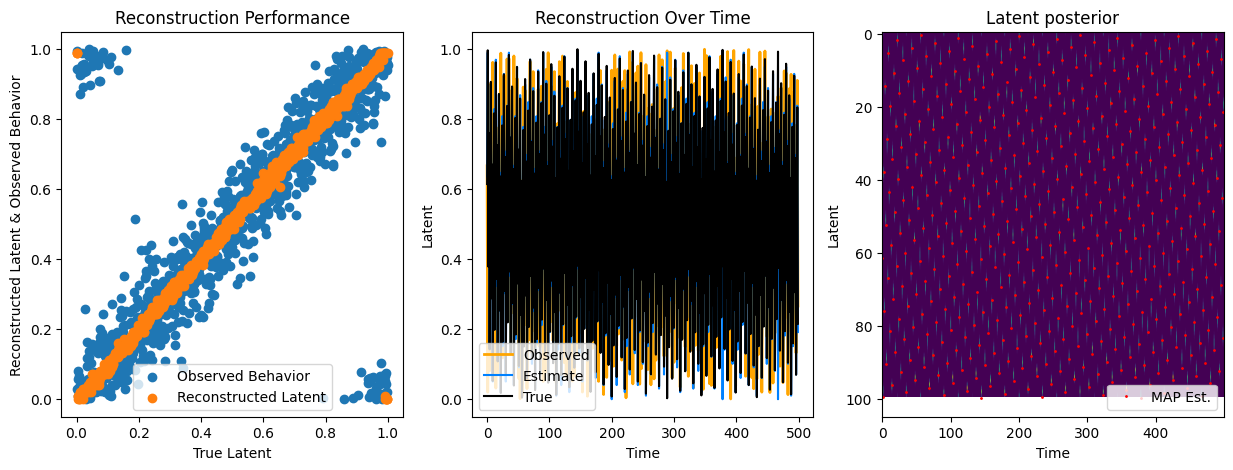

In [ ]:
utils.plot_objhist(model);
utils.plot_real_tuning(model, true_tunings, ys)
utils.plot_latent_recon_sim(model, ys, xs_true)